In [213]:
# 1: importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_theme(
    style="whitegrid",
    palette="pastel"
)

plt.figure(figsize=(12, 8))

plt.tight_layout()
plt.rcParams["font.family"] = "DejaVu Sans"

<Figure size 1200x800 with 0 Axes>

In [214]:
# 2: data importing and exploring

try: 
    df = pd.read_csv("../data/superstore.csv", encoding='latin-1')
except FileNotFoundError:
    print("File not found")


# df.head()
# df.isnull().sum()
df.dtypes
# df.describe()
# df.columns
# df.head()

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [215]:
# 3: data cleaning
df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(
            df['Order Date'],
            format='%m/%d/%Y'
        )

df['Order Date'] = df['Order Date'].dt.strftime('%Y-%m-%d')

# print(df['Order Date'].dtype)

df['Ship Date'] = pd.to_datetime(
            df['Ship Date'],
            format='%m/%d/%Y'
    )

df['Ship Date'] = df['Ship Date'].dt.strftime('%Y-%m-%d')

# print(df['Ship Date'].dtype)

# df.dtypes

In [216]:
# SQLite connection
try:
    conn = sqlite3.connect(':memory:')
    print('Connection made')
    df.to_sql('superstore', conn, if_exists='replace', index=False)
    print('BD criada')

except:
    print('Impossivel conectar ao SQLite')



Connection made
BD criada


In [217]:
# Executes queries
# P.S.: run this section before running any query from the business questions

def execute(query):
    try:
        result = pd.read_sql_query(query, conn)
        return result
    except:
        print('Erro ao ler query')

In [218]:
# 4: business questions

# 1. Which region generates the most total sales?
query = """
        SELECT Region, max(total_sales) AS "Total Sales"
        FROM ( 
            SELECT
                Region,
                ROUND(SUM(sales), 2) AS total_sales
            FROM superstore
            GROUP BY region
        ) AS maxi
    """

execute(query)


,Region,Total Sales
0,West,725457.82


In [219]:
# 2. What are the top 5 products by total revenue?
query = """
        SELECT
            "Product Name",
            ROUND(SUM(profit), 2) AS Revenue
        FROM superstore
        GROUP BY "Product Name"
        ORDER BY revenue DESC
        LIMIT 5
    """

execute(query)

,Product Name,Revenue
0,Canon imageCLASS 2200 Advanced Copier,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04
2,Hewlett Packard LaserJet 3310 Copier,6983.88
3,Canon PC1060 Personal Laser Copier,4570.93
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98


In [220]:
# 3. What do monthly sales trends look like over time?
query = """
        SELECT
            substr(
                'JanFebMarAprMayJunJulAugSepOctNovDec',
                1 + 3*(strftime('%m', datetime("Order Date")) - 1),
                3
            ) AS Month,

            strftime('%Y', datetime("Order Date")) AS Year,
            ROUND(SUM(Sales), 2) AS "Month-Year Sales"
        FROM superstore
        GROUP BY Year, Month
        ORDER BY Year, strftime('%m', datetime("Order Date"))
    """

output3 = execute(query)

output3

,Month,Year,Month-Year Sales
0,Jan,2014,14236.90
1,Feb,2014,4519.89
2,Mar,2014,55691.01
3,Apr,2014,28295.35
4,May,2014,23648.29
5,Jun,2014,34595.13
6,Jul,2014,33946.39
7,Aug,2014,27909.47
8,Sep,2014,81777.35
9,Oct,2014,31453.39


In [221]:
# 4. Which category has the best profit margin?
query = """
        SELECT
            Category,
            MAX(Profit_Margin) AS "Best Profit Margin (%)"
        FROM (
            SELECT
                Category,
                ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
            FROM superstore
            GROUP BY Category
        ) AS PF
    """

execute(query)

,Category,Best Profit Margin (%)
0,Technology,17.4


In [222]:
# 5. Which sub-categories are losing money?
query = """
        SELECT
            "Sub-Category",
            ROUND(SUM(Profit), 2) AS "Total Profit"
        FROM superstore
        GROUP BY "Sub-Category"
        HAVING "Total Profit" < 0
        ORDER BY "Sub-Category";
    """

execute(query)

,Sub-Category,Total Profit
0,Bookcases,-3472.56
1,Supplies,-1189.10
2,Tables,-17725.48


In [223]:
# 6. Does offering a higher discount actually hurt profit?
query = """
        SELECT
            CASE
                WHEN Discount < 0.1 THEN '0-10%'
                WHEN Discount < 0.2 THEN '10-20%'
                WHEN Discount < 0.3 THEN '20-30%'
                WHEN Discount < 0.4 THEN '30-40%'
                ELSE '50+%'
            END AS "Discount Range",
            ROUND(AVG(Profit), 2) AS "Profit Average",
            Count(*) AS "Number of Orders"
        FROM superstore
        GROUP BY "Discount Range"
    """

execute(query)

,Discount Range,Profit Average,Number of Orders
0,0-10%,66.90,4798
1,10-20%,71.56,146
2,20-30%,24.70,3657
3,30-40%,-50.24,254
4,50+%,-107.65,1139


In [224]:
# 7. Which customer segment (Consumer, Corporate, Home Office) is most valuable?
query = """
        SELECT
            Segment,
            ROUND(SUM(Profit), 2) AS "Total Profit",
            ROUND(AVG(Profit), 2) AS "Average Profit",
            COUNT(*) AS "Number of Orders"
        FROM superstore
        GROUP BY Segment
        ORDER BY "Total Profit" DESC
    """

execute(query)

,Segment,Total Profit,Average Profit,Number of Orders
0,Consumer,134119.21,25.84,5191
1,Corporate,91979.13,30.46,3020
2,Home Office,60298.68,33.82,1783


In [225]:
# 8. What's the average order value per region?

query = """
        SELECT
            Region,
            ROUND(SUM(Sales) / COUNT(*), 2) AS "Average Order Value"
        FROM superstore
        GROUP BY Region
        ORDER BY Region
    """

execute(query)

,Region,Average Order Value
0,Central,215.77
1,East,238.34
2,South,241.80
3,West,226.49


In [226]:
# 9. Which shipping mode is used most, and does it correlate with order size?

query = """
        SELECT
            "Ship Mode",
            COUNT(*) AS "Number of Orders",
            ROUND(AVG(Quantity), 2) AS "Order Size Average"
        FROM superstore
        GROUP BY "Ship Mode"
        ORDER BY "Number of Orders" DESC
    """

execute(query)

,Ship Mode,Number of Orders,Order Size Average
0,Standard Class,5968,3.82
1,Second Class,1945,3.82
2,First Class,1538,3.70
3,Same Day,543,3.61


In [227]:
# 10. Which state has the most orders but lowest profit? (hidden underperformer)

query = """
        SELECT
            "State",
            COUNT(*) AS "Number of Orders",
            ROUND(SUM(Profit), 2) AS "Total Profit"
        FROM superstore
        GROUP BY State
        ORDER BY "Number of Orders" DESC, "Total Profit" ASC
    """

execute(query)

,State,Number of Orders,Total Profit
0,California,2001,76381.39
1,New York,1128,74038.55
2,Texas,985,-25729.36
3,Pennsylvania,587,-15559.96
4,Washington,506,33402.65
5,Illinois,492,-12607.89
6,Ohio,469,-16971.38
7,Florida,383,-3399.30
8,Michigan,255,24463.19
9,North Carolina,249,-7490.91


In [228]:
# 5. NumPy analysis

sales = df['Sales'].to_numpy()
profits = df['Profit'].to_numpy()

print(sales[:5])
print(profits[:5])

[261.96   731.94    14.62   957.5775  22.368 ]
[  41.9136  219.582     6.8714 -383.031     2.5164]


In [229]:
# Stats

# Average sales and profit
print(f"Average sales: ${np.mean(sales):.2f}")
print(f"Average profit: ${np.mean(profits):.2f}")
print()

# Median sales and profit
print(f"Median sales: ${np.median(sales):.2f}")
print(f"Median profit: ${np.median(profits):.2f}")
print()

# Deviation
print(f"Deviation sales: ${np.std(sales):.2f}")
print(f"Deviation profit: ${np.std(profits):.2f}")
print()

Average sales: $229.86
Average profit: $28.66

Median sales: $54.49
Median profit: $8.67

Deviation sales: $623.21
Deviation profit: $234.25



In [230]:
# Percentiles

# quartiles for sales
sales_q1, sales_q2, sales_q3, sales_q4 = np.percentile(sales, [25, 50, 75, 100])

print('Sales Quartiles:')
print(f"1/4 quartiles: ${sales_q1:.2f}")
print(f"2/4 quartiles: ${sales_q2:.2f}")
print(f"3/4 quartiles: ${sales_q3:.2f}")
print(f"4/4 quartiles: ${sales_q4:.2f}")


# quartiles for profits
profits_q1, profits_q2, profits_q3, profits_q4 = np.percentile(profits, [25, 50, 75, 100])

print('\nProfis Quartiles:')
print(f"1/4 quartiles: ${profits_q1:.2f}")
print(f"2/4 quartiles: ${profits_q2:.2f}")
print(f"3/4 quartiles: ${profits_q3:.2f}")
print(f"4/4 quartiles: ${profits_q4:.2f}")

Sales Quartiles:
1/4 quartiles: $17.28
2/4 quartiles: $54.49
3/4 quartiles: $209.94
4/4 quartiles: $22638.48

Profis Quartiles:
1/4 quartiles: $1.73
2/4 quartiles: $8.67
3/4 quartiles: $29.36
4/4 quartiles: $8399.98


In [231]:
# Percentage of sales above average

pct = np.mean(sales > np.mean(sales)) * 100
print(f"\nThe percentage of sales above average is: {pct:.2f}%")


The percentage of sales above average is: 23.61%


In [232]:
# High/Low flags

# for sales

df['Sales Tier'] = np.where(sales >= sales_q3, 'High', 'Low')

print('\nSales Tier distribution:')
print(df['Sales Tier'].value_counts())

# for profits

df['Profits Tier'] = np.where(profits >= profits_q3, 'High', 'Low')
df['isProfitable'] = np.where(df['Profit'] > 0, 'Yes', 'No')

print('\nProfits Tier distribution:')

print(df['Profits Tier'].value_counts())
print()
print(df['isProfitable'].value_counts())


Sales Tier distribution:
Sales Tier
Low     7494
High    2500
Name: count, dtype: int64

Profits Tier distribution:
Profits Tier
Low     7494
High    2500
Name: count, dtype: int64

isProfitable
Yes    8058
No     1936
Name: count, dtype: int64


In [233]:
# Weighted average profit per sales

avg = np.average(profits, weights=sales)
print(f'\nAverage profit per sales (weighted): ${avg:.2f}')


Average profit per sales (weighted): $332.92


In [234]:
# Correlation between discount and profits

discount = df['Discount'].to_numpy()
correlation = np.corrcoef(discount, profits)[0, 1]

print(f'\nCorrelation between discount and profits: {correlation:.2f}')


Correlation between discount and profits: -0.22


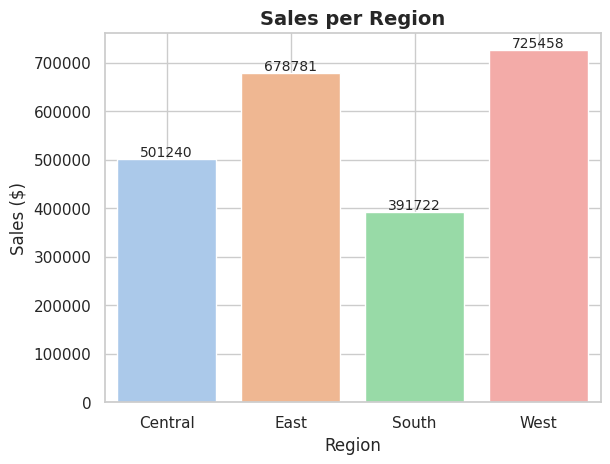

In [235]:
# 6. Visualizations

# 6.1. Sales per region
sales_region = df.groupby("Region")["Sales"].sum().reset_index()

ax = sns.barplot(
    x="Region",
    y="Sales",
    data=sales_region,
    hue="Region",
    palette="pastel"
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="edge",
        fontsize=10
    )

plt.title(
    "Sales per Region",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)
plt.grid(True)
plt.show()


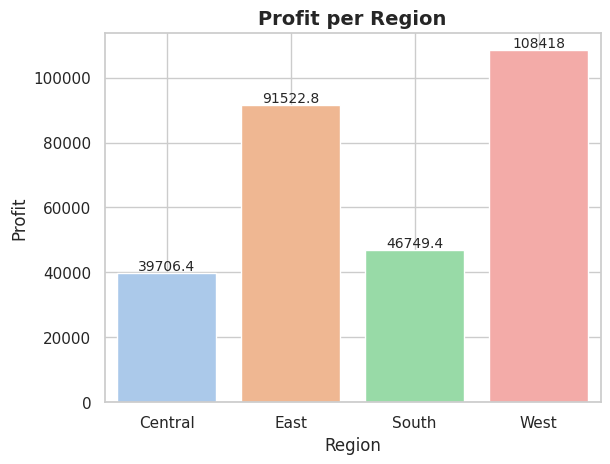

In [236]:
# 6.2. Profit by Region
profit_reg = df.groupby("Region")["Profit"].sum().reset_index()

ax = sns.barplot(
    x="Region",
    y="Profit",
    data=profit_reg,
    hue="Region",
    palette="pastel"
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="edge",
        fontsize=10
    )

plt.title(
    "Profit per Region",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)
plt.show()

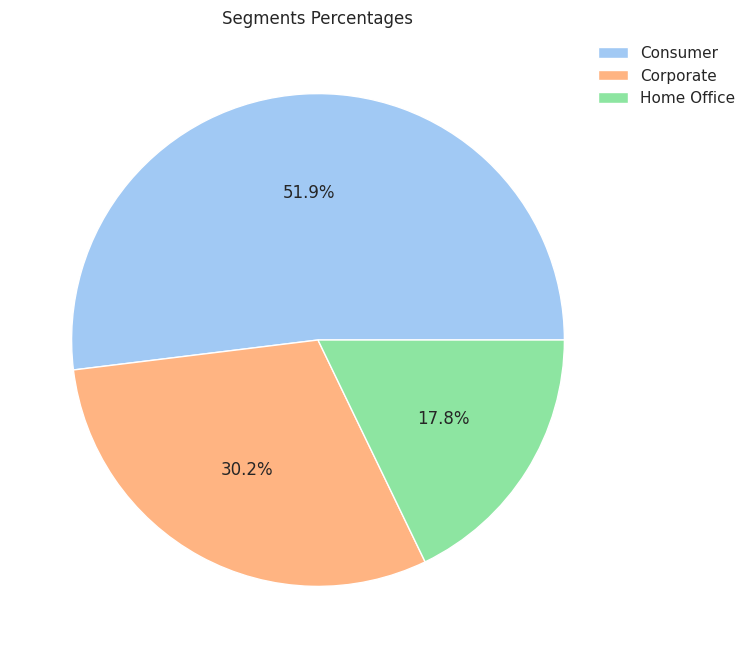

In [237]:
# 6.3. Segments pcts
seg = df.groupby("Segment")["Order ID"].count().reset_index()

plt.figure(figsize=(8, 8))

plt.pie(
    seg["Order ID"],
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)

plt.title("Segments Percentages")

plt.legend(
    labels=seg["Segment"],
    loc="upper right",
    bbox_to_anchor=(1.2, 1),
    frameon=False
)

plt.show()

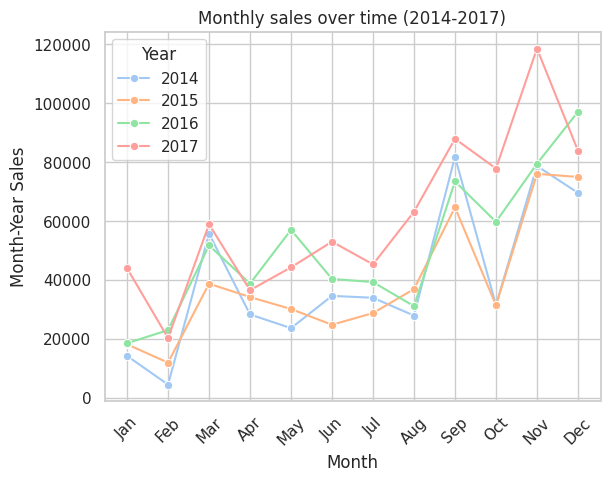

In [238]:
# 6.4. Monthly sales over time (2014-2017)
sales = output3

sns.lineplot(
    x="Month",
    y="Month-Year Sales",
    hue="Year",
    data=sales,
    marker="o",
    palette="pastel"
)

plt.title("Monthly sales over time (2014-2017)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

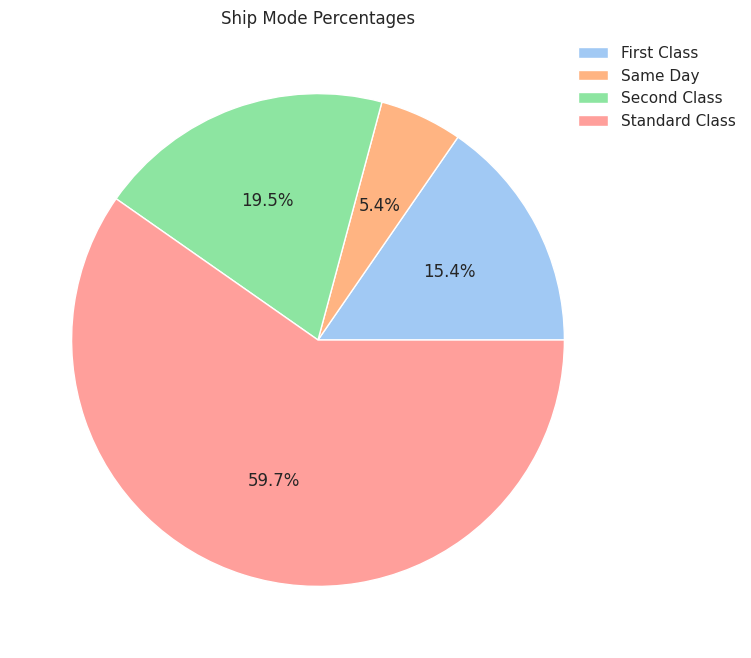

In [239]:
# 6.5. Ship Mode pcts
ship = df.groupby("Ship Mode")["Order ID"].count().reset_index()

plt.figure(figsize=(8, 8))

plt.pie(
    ship["Order ID"],
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)

plt.legend(
    labels=ship["Ship Mode"],
    loc="upper right",
    bbox_to_anchor=(1.2, 1),
    frameon=False
)

plt.title("Ship Mode Percentages")
plt.show()